<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка</a></span></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Обучение</a></span></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Выводы</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Чек-лист проверки</a></span></li></ul></div>

# Проект для «Викишоп»

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию. 

Обучите модель классифицировать комментарии на позитивные и негативные. В вашем распоряжении набор данных с разметкой о токсичности правок.

Постройте модель со значением метрики качества *F1* не меньше 0.75. 

**Инструкция по выполнению проекта**

1. Загрузите и подготовьте данные.
2. Обучите разные модели. 
3. Сделайте выводы.

Для выполнения проекта применять *BERT* необязательно, но вы можете попробовать.

**Описание данных**

Данные находятся в файле `toxic_comments.csv`. Столбец *text* в нём содержит текст комментария, а *toxic* — целевой признак.

## Подготовка

In [3]:
!pip install -q spacy

In [58]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 424.9 kB/s eta 0:00:0000:0100:02
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import nltk
from nltk.corpus import stopwords as nltk_stopwords
from sklearn.linear_model import LinearRegression
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
import spacy
from tqdm import tqdm

In [60]:
import warnings
warnings.filterwarnings("ignore")

In [61]:
NJOBS = -1 # для одновременной работы всех ядер процессора при обучении моделей(для увеличения скорости) 
RANDOM = 12345
ITERATIONS = 3 #grid search iteration

In [62]:
data = pd.read_csv('toxic_comments.csv', index_col=0)

In [63]:
data.head()

,text,toxic
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0


In [64]:
data.shape

(159292, 2)

In [65]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 159292 entries, 0 to 159450
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    159292 non-null  object
 1   toxic   159292 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.6+ MB


In [66]:
# частота распределения классов в целевом значении:

data['toxic'].value_counts(normalize=True)

toxic
0    0.898388
1    0.101612
Name: proportion, dtype: float64

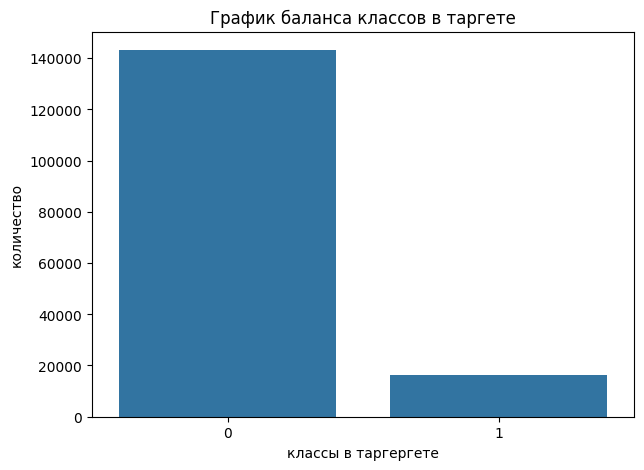

In [67]:
# график частоты встречаемости классов:

plt.figure(figsize=(7,5))
sns.countplot(data=data,
              x='toxic')
plt.title('График баланса классов в таргете')
plt.xlabel('классы в таргергете', size=10)
plt.ylabel('количество', size=10);

Наблюдаем явный дисбаланс классов

<div class="alert alert-success">
<font size="5"><b>Комментарий ревьюера</b></font>

Успех:

 
Плюс за  проверку на сбалансированность 

 



<div class="alert alert-warning">

Совет: 



 


- можно также посчитать количество слов в предложений,  длину слов в твите, опять же в разбивке по Таргету.  Если будут какие-то сильные отличия, возможно из-за этого стоит сгенерировать дополнительные признаки для наших моделей. Или например можно использовать библиотеку SentimentIntensityAnalyzer для оценки сантиментов, и посмотреть насколько хорошо ее оценки корелирует с нашими таргетами
   
   
- когда мы работаем с текстами, describe итп описательные статистике не использовать, но можно провести частотный анализ текста.  Предлагаю для этого использовать [облако слов](https://habr.com/ru/post/517410/) - чтобы получить общее представление о тематике и о наиболее часто встречаемых словах в токсичных и нетоксичных твитах (в облаке уже автоматически будут убраны стоп слова). Кроме того графики, рисунки делают проект визуально интересней
   
   
В тренажере облако импортируем так

    !pip install wordcloud 


или

    !pip install wordcloud==1.8.2.2  


И возможно дополнительно надо будет сделать



    !pip install --upgrade Pillow  (попробуй версию 9.5.0)

     


# Лемматизируем данные

С помощью библиотеки SpaCy, как более быстрой и удобной в отличие от pymystem3:

In [68]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [69]:
# функция для очистки текста:

def clear_text(text):
    # приводим все в нижний регистр и оставляем только латинницу:
    text = text.lower() 
    text = ' '.join(re.sub(r'[^a-z]', ' ', text).split()) 
    
    # исключаем артикли the И a:
    text = text.replace(' a ', ' ' )
    text = text.replace('a ', '')
    text = text.replace(' the ', ' ')
    text = text.replace('the ', '')
    
    # исключаем повторные пробелы и пробелы в начале и конце строк:
    text = re.sub(' +', ' ', text)
    text = text.strip()
    return text

In [70]:
# добавим в датафрейм столбец с очищенным текстом:

data['clear'] = [clear_text(text) for text in tqdm(data['text'])]

100%|████████████████████████████████| 159292/159292 [00:03<00:00, 40935.87it/s]


In [71]:
# проверка:

data['clear'].head(5)

0    explanation why edits made under my username h...
1    d aww he matches this background colour i m se...
2    hey man i m really not trying to edit war it s...
3    more i can t make any real suggestions on impr...
4    you sir are my hero any chance you remember wh...
Name: clear, dtype: object

In [72]:
# функция лемматизации очищенного текста"

def lemmatize(text):
    lemmatized_tokens = ' '.join([token.lemma_ for token in nlp(text)])
    return lemmatized_tokens

In [73]:
# добавим столбец с лемматизированным текстом в датафрейм:
try:
    data = pd.read_csv('data_lemm.csv')
except:
    data['lemm'] = data['clear'].apply(lemmatize)
    data.to_csv('data_lemm.csv', index=False)

data['lemm'].head(10)

0    explanation why edit make under my username ha...
1    d aww he match this background colour I m seem...
2    hey man I m really not try to edit war it s ju...
3    more I can t make any real suggestion on impro...
4    you sir be my hero any chance you remember wha...
5     congratulation from I as well use tool well talk
6         cocksucker before you piss around on my work
7    your vandalism to matt shirvington article hav...
8    sorry if word nonsense be offensive to you any...
9    alignment on this subject and which be contrar...
Name: lemm, dtype: object

In [74]:
data = data[['text', 'lemm', 'toxic']]

In [75]:
data.sample()

,text,lemm,toxic
30850,"""When editing an article on Wikipedia there is...",when edit an article on wikipedithere be small...,0


In [76]:
# явные дубликаты:
data.duplicated().sum()
data = data.drop_duplicates()

In [77]:
# пропуски:
print(data.isna().sum())
data = data.dropna()

text      0
lemm     11
toxic     0
dtype: int64


<div class="alert alert-success">
<font size="5"><b>Комментарий ревьюера</b></font>

Успех:


- Spacy отличный выбор, в отличие от того же WordNetLemmatizer  Не надо мучиться с предварительной такенизацией, и учётом пос тегов 


 
- Плюс за использование apply, неэффективные циклы нам ни к чему/Хорошая идея с сохранением файла


- Да, всегда лучше проверить что получилось  в итоге, так всегда будет возможность поправить ошибку

    
    
<div class="alert alert-warning">


Совет: 


    
- попробуй .progress_apply, делает что .apply, но еще и показывает на какой итерации находится процесс.  

Для некоторых версий, чтобы заработал .progress_apply предварительно нужно сделать:
    
    
    from tqdm.notebook import tqdm
    tqdm.pandas()
     

# Вывод:

* загружены необходимые библиотеки и данные.
* исследован баланс классов в целевом признаке.
* текст очищен и лемматизирован.
* данные проверены на явные дубликаты и пропуски.
* в выборке оставлены только нужные для дальнейшей работы столбцы.

## Обучение

In [78]:
train, test = train_test_split(data, test_size=0.25, random_state = RANDOM)
print(train.shape, test.shape)

(119460, 3) (39821, 3)


In [79]:
#рабочие и таргетные столбцы:

X_train = train['lemm']
y_train = train['toxic']

X_test = test['lemm']
y_test = test['toxic']

In [80]:
# загрузим фильтр стоп-слов:
nltk.download('stopwords')
stopwords = nltk_stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/alexey/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# TF-IDF + LogisticRegression

In [99]:
pipe_lg = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=stopwords)),
    ('logisticregression', LogisticRegression(random_state=RANDOM,
                                              class_weight='balanced',
                                              max_iter=50,
                                              n_jobs=None))
    ])

param_lg = {
    'logisticregression__C': range(1, 10, 2),
    'tfidf__max_features': [100000],
    'tfidf__ngram_range': [(1, 1)]
}

In [100]:
rs_lg = RandomizedSearchCV(
    pipe_lg, 
    param_distributions=param_lg, 
    scoring='f1',
    cv=3,
    n_iter=ITERATIONS,
    verbose=3,
    random_state=RANDOM
)

<div class="alert alert-success">
<font size="5"><b>Комментарий ревьюера</b></font>

Успех:




 

Корректно использован RandomizedSearchCV + pipeline. Есть и другие варианты, тюнинга гиперпараметров, можешь [ознакомиться](https://www.freecodecamp.org/news/hyperparameter-optimization-techniques-machine-learning/)
    
    
    
- не забыт random_state


- class_weight = 'balanced'


- scoring = 'f1'

    

<div class="alert alert-warning">


 

Совет: 



 
    
 Можешь попробовать  feature_engenering (это когда мы создаём собственные признаки. Во многих случаях это более эффективный способ повысить нашу метрику. Для данного проекта это   не работает, метрика не улучшится,  но можно   попрактиковаться, вспомнить ColumnsTransformer, покреативить в деле создания признаков. Например посчитать количество слов  (Как будто бы в токсичных твитах слов меньше) итд итп или получить сентиментальную оценку текста с помощью  SentimentIntensityAnalyzer  
    
И добавить это в качестве дополнительных признаков      

In [101]:
%%time
rs_lg.fit(X_train, y_train)
print(f'''Лучшие гиперпараметры модели LogisticRegression+TF-IDF: {rs_lg.best_params_},
Лучшая метрика f1 модели LogisticRegression+TF-IDF: {rs_lg.best_score_}''')

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV 1/3] END logisticregression__C=1, tfidf__max_features=100000, tfidf__ngram_range=(1, 1);, score=0.742 total time=   2.8s
[CV 2/3] END logisticregression__C=1, tfidf__max_features=100000, tfidf__ngram_range=(1, 1);, score=0.746 total time=   2.7s
[CV 3/3] END logisticregression__C=1, tfidf__max_features=100000, tfidf__ngram_range=(1, 1);, score=0.747 total time=   2.6s
[CV 1/3] END logisticregression__C=9, tfidf__max_features=100000, tfidf__ngram_range=(1, 1);, score=0.758 total time=   2.9s
[CV 2/3] END logisticregression__C=9, tfidf__max_features=100000, tfidf__ngram_range=(1, 1);, score=0.759 total time=   3.0s
[CV 3/3] END logisticregression__C=9, tfidf__max_features=100000, tfidf__ngram_range=(1, 1);, score=0.760 total time=   3.0s
[CV 1/3] END logisticregression__C=7, tfidf__max_features=100000, tfidf__ngram_range=(1, 1);, score=0.760 total time=   3.3s
[CV 2/3] END logisticregression__C=7, tfidf__max_features=100000, 

# TF-IDF + DecisionTreeClassifier

In [88]:
# создадим пайплайн с признаками TF-IDF:
dtr_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=stopwords)),
    ('dtr', DecisionTreeClassifier(random_state=RANDOM, class_weight='balanced'))
])

In [89]:
# сетка параметров для поиска наилучших:

param_grid = {
    'tfidf__max_features': [100000],
    'tfidf__ngram_range': [(1, 1)],
    'dtr__max_depth': [5, 10],
}

In [90]:
# использование RandomizedSearchCV для поиска по сетке:

dtr_rs = RandomizedSearchCV(dtr_pipe,
                           param_distributions=param_grid,
                           scoring='f1',
                           cv=3,
                           n_iter=ITERATIONS,
                           random_state=RANDOM,
                           verbose=3)

In [91]:
%%time
dtr_rs.fit(X_train, y_train)

Fitting 3 folds for each of 2 candidates, totalling 6 fits
[CV 1/3] END dtr__max_depth=5, tfidf__max_features=100000, tfidf__ngram_range=(1, 1);, score=0.441 total time=   3.4s
[CV 2/3] END dtr__max_depth=5, tfidf__max_features=100000, tfidf__ngram_range=(1, 1);, score=0.454 total time=   3.3s
[CV 3/3] END dtr__max_depth=5, tfidf__max_features=100000, tfidf__ngram_range=(1, 1);, score=0.456 total time=   3.3s
[CV 1/3] END dtr__max_depth=10, tfidf__max_features=100000, tfidf__ngram_range=(1, 1);, score=0.548 total time=   4.4s
[CV 2/3] END dtr__max_depth=10, tfidf__max_features=100000, tfidf__ngram_range=(1, 1);, score=0.563 total time=   4.4s
[CV 3/3] END dtr__max_depth=10, tfidf__max_features=100000, tfidf__ngram_range=(1, 1);, score=0.574 total time=   4.3s
CPU times: user 28.2 s, sys: 340 ms, total: 28.6 s
Wall time: 28.6 s


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('tfidf',
                                              TfidfVectorizer(stop_words=['a',
                                                                          'about',
                                                                          'above',
                                                                          'after',
                                                                          'again',
                                                                          'against',
                                                                          'ain',
                                                                          'all',
                                                                          'am',
                                                                          'an',
                                                                          'and',
                                                                          'any',
                                                                          'are',
                                                                          'aren',
                                                                          "aren't",
                                                                          'as',
                                                                          'at',
                                                                          'be',
                                                                          'because',
                                                                          'been',
                                                                          'before',
                                                                          'being',
                                                                          'below',
                                                                          'between',
                                                                          'both',
                                                                          'but',
                                                                          'by',
                                                                          'can',
                                                                          'couldn',
                                                                          "couldn't", ...])),
                                             ('dtr',
                                              DecisionTreeClassifier(class_weight='balanced',
                                                                     random_state=12345))]),
                   n_iter=3,
                   param_distributions={'dtr__max_depth': [5, 10],
                                        'tfidf__max_features': [100000],
                                        'tfidf__ngram_range': [(1, 1)]},
                   random_state=12345, scoring='f1', verbose=3)

In [92]:
dtr_rs.best_params_

{'tfidf__ngram_range': (1, 1),
 'tfidf__max_features': 100000,
 'dtr__max_depth': 10}

In [93]:
dtr_rs.best_score_

0.5614850016805052

In [94]:
print(f'Метрика F1 для кросс-валидации TF-IDF + DecisionTreeClassifier', dtr_rs.best_score_)

Метрика F1 для кросс-валидации TF-IDF + DecisionTreeClassifier 0.5614850016805052


In [103]:
# приведем результаты в общую таблицу:

result = pd.DataFrame({'F1-score' : [dtr_rs.best_score_, rs_lg.best_score_]},
                                     index=['TF-IDF+DTC', 'TF-IDF+LR'])
result

,F1-score
TF-IDF+DTC,0.561485
TF-IDF+LR,0.759148


* в результате обучения, лучшей моделью оказалась LogisticRegression с F1-score=0.76

## Выводы

In [104]:
# предсказание на тестовой выборке
pred = rs_lg.predict(X_test)

In [105]:
f1_score = f1_score(y_test, pred)
f1_score

0.7505638249887235

* лучшая модель Логистической Регресии прошла проверку на тестовой выборке с результатом F1-score = 0.7525

<div class="alert alert-success">
<font size="5"><b>Комментарий ревьюера</b></font>

Успех: 

- Все верно, логика моделирования не нарушена, тут тестируем только лучшую модель отобранную на валидации, или парочку лучших, если на валидации результаты близки

 

- Если студент получил на тесте f1 выше 0,75, это считается приемлемым результатом.


<div class="alert alert-warning">



Совет: 


Что может помочь добиться лучшего результата (от простого)? 

 
- можно поиграться [порогом](https://machinelearningmastery.com/threshold-moving-for-imbalanced-classification/). Ещё можешь посмотреть в [туториале](https://scikit-learn.org/stable/modules/classification_threshold.html). Есть несколько вариантов, главное не использовать для подбора порога тестовую выборку, ведь это будет подгонка. Таким образом можно поднять метрику на процент - полтора
   
 


    
- попробовать другие модели. проект своеобразный выбор между вычислительными ограничениями (много примеров, расчеты могут затянуться) и задачей получить хорошую метрику. С этой точки зрения  интересная [моделька](https://medium.com/geekculture/passive-aggressive-algorithm-for-big-data-models-8cd535ceb2e6) (открывается с помощью VPN) [или](https://datafinder.ru/products/passivno-agressivnyy-klassifikator-v-mashinnom-obuchenii). Она считается очень шустрой     
    


- использование предбученной модели Берта, выбрав соответствующую модель и используя полученные эмбединги, даже на небольшом тренировочном датасете можно обучить модель, которая на test покажет хорошую метрику. В этом случаи можно сразу получить метрику > 0.95 (при правильно выбранной модели)







<div class="alert alert-warning">
<font size="5"><b>Комментарий ревьюера</b></font>


Совет: 

 





А ещё можешь посмотреть какие слова  является наиболее важным для классификации с точки зрения модели. Получаем список слов (Так как у тебя pipeline то предварительно разбиваем его на части)    
    
    
    
    words = Твоя модель.best_estimator_.named_steps['Имя викторизатора'].get_feature_names_out()

    
    
    
Получаем коэффициенты важности (для логистической регрессии)    
    
    weights = Твоя модель.best_estimator_.named_steps['имя модели'].coef_[0]


(подробно как можно вытаскивать имена [тут](https://medium.com/mlearning-ai/get-column-name-after-fitting-the-machine-learning-pipeline-145a2a8051cc))


А потом можно построить такой-то красивый график с помощью     seaborn

 

Выполнено следующее:

* Рабочий датасет загружен и прлверен на пропуски и нулевые значения.
* Исследован балланс классов в таргете.
* Проведена лемматизация данных.
* Данные разбиты на трейновую и тестовую выборки.
* Твиты очищены от стоп-слов.
* Применена TF-IDF + LogisticRegression и TF-IDF + DecisionTreeClassifier
* В результате требованию по F1-score >= 0.75 соответствовала модель Логистичесской регрессии.
* Также лучшая модель Логистичесской регрессии была проверена на тесте с F1-score = 0.752.


<div class="alert alert-info">
<font size="5"><b>Комментарий ревьюера</b></font>



Алексей, у тебя старательно выполненная работа, все четко, осмысленно. 


 
Очистка и лемматизация проведена корректно


 
Выводы присутствуют, они четкие и подробные.


Логика моделирования не нарушена, RS использован корректно. И здорово что он использован  вместе с pipeline 
    
    
    


Оставил несколько советов:



 


- попробуй очень современный и модный сейчас подход с использованием  Берта. Есть несколько вариантов, самый эффективный - это использовать эмбединги (как замена TFIDF) для этого есть уже готовый код в тренажёре (в этом случае разрешается сильно порезать датасет, а если еще и использовать GPU в Colab код можно прогнать за полчаса).



- для красивой  визуализации можешь построить облако для токсичных и нетоксичных комментариев



- чтобы заглянуть внутрь модели, можешь посмотреть какой из признаков является наиболее важный для логистической регресси (должно получиться слово fuck)   


 



Посылаю на вторую итерацию, чтобы ответить на вопросы если они появятся, на связи.




 

<font color='green'><b>Полезные (и просто интересные) материалы:</b> \
Для работы с текстами используют и другие подходы. Например, сейчас активно используются RNN (LSTM) и трансформеры (BERT и другие с улицы Сезам, например, ELMO). НО! Они не являются панацеей, не всегда они нужны, так как и TF-IDF или Word2Vec + модели из классического ML тоже могут справляться. \
BERT тяжелый, существует много его вариаций для разных задач, есть готовые модели, есть надстройки над библиотекой transformers. Если, обучать BERT на GPU (можно в Google Colab или Kaggle), то должно быть побыстрее.\
https://huggingface.co/transformers/model_doc/bert.html \
https://t.me/renat_alimbekov \
https://colah.github.io/posts/2015-08-Understanding-LSTMs/ - Про LSTM \
https://web.stanford.edu/~jurafsky/slp3/10.pdf - про энкодер-декодер модели, этеншены\
https://pytorch.org/tutorials/beginner/transformer_tutorial.html - официальный гайд
по трансформеру от создателей pytorch\
https://transformer.huggingface.co/ - поболтать с трансформером \
Библиотеки: allennlp, fairseq, transformers, tensorflow-text — множествореализованных
методов для трансформеров методов NLP \
Word2Vec https://radimrehurek.com/gensim/models/word2vec.html 


Если понравилась работа с текстами, то можешь посмотреть очень интересный (но очень-очень сложный) курс лекций: https://github.com/yandexdataschool/nlp_course .

Если нравится смотреть и слушать то есть целый курс на Ютубе https://www.youtube.com/watch?v=qDMwIQRQt-M&list=PLEwK9wdS5g0qksxWxtE5c2KuFkIfUXe3i&index=1


## Чек-лист проверки

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке исполнения
- [x]  Данные загружены и подготовлены
- [x]  Модели обучены
- [x]  Значение метрики *F1* не меньше 0.75
- [x]  Выводы написаны